DL LAB 04

Before Cleaning Shape: (3000, 2)
After Cleaning Shape: (2999, 2)
Learning Rate: 0.001 | Test Accuracy: 0.8333
Learning Rate: 0.01 | Test Accuracy: 0.8333
Learning Rate: 0.1 | Test Accuracy: 0.8333


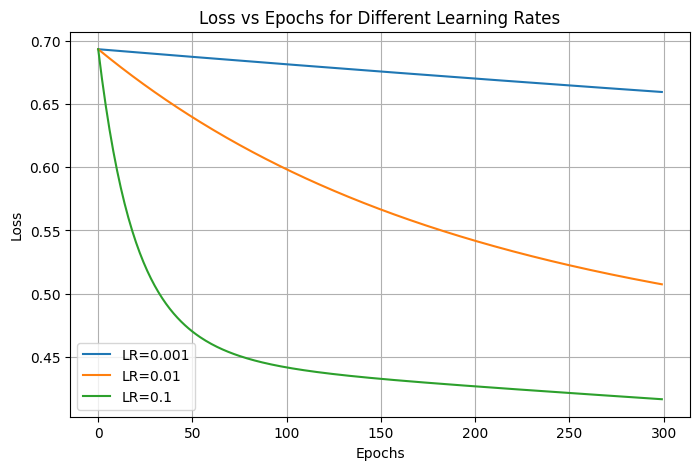


Best Learning Rate: 0.001
Final Test Accuracy: 0.8333333333333334


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("spam_or_not_spam.csv")

print("Before Cleaning Shape:", df.shape)

missing_labels = df[df['label'].isnull()]
df = df.dropna()
df['email'] = df['email'].astype(str)

print("After Cleaning Shape:", df.shape)

X_text = df['email']
y = df['label'].values.reshape(-1, 1)

from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
X = vectorizer.fit_transform(X_text).toarray()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y, y_pred):
    m = len(y)
    return - (1/m) * np.sum(y*np.log(y_pred+1e-9) + (1-y)*np.log(1-y_pred+1e-9))

def compute_accuracy(y, y_pred):
    preds = (y_pred > 0.5).astype(int)
    return np.mean(preds == y)

def train(X, y, lr, epochs=300):
    m, n = X.shape
    W = np.zeros((n, 1))
    b = 0

    losses = []
    accuracies = []

    for i in range(epochs):
        z = np.dot(X, W) + b
        y_pred = sigmoid(z)

        loss = compute_loss(y, y_pred)
        acc = compute_accuracy(y, y_pred)

        losses.append(loss)
        accuracies.append(acc)

        dW = (1/m) * np.dot(X.T, (y_pred - y))
        db = (1/m) * np.sum(y_pred - y)

        W = W - lr * dW
        b = b - lr * db

    return W, b, losses, accuracies

learning_rates = [0.001, 0.01, 0.1]
results = {}
all_losses = {}

for lr in learning_rates:
    W, b, losses, accs = train(X_train, y_train, lr)
    all_losses[lr] = losses

    y_pred_test = sigmoid(np.dot(X_test, W) + b)
    acc = compute_accuracy(y_test, y_pred_test)

    results[lr] = acc
    print(f"Learning Rate: {lr} | Test Accuracy: {acc:.4f}")

plt.figure(figsize=(8,5))

for lr in learning_rates:
    plt.plot(all_losses[lr], label=f"LR={lr}")

plt.title("Loss vs Epochs for Different Learning Rates")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

best_lr = max(results, key=results.get)
print("\nBest Learning Rate:", best_lr)
print("Final Test Accuracy:", results[best_lr])
